<a href="https://colab.research.google.com/github/umachandola249/IIT_BS_Machine_Learning/blob/main/end_to_end_ml_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("shambhurajejagadale/student-performance-prediction-dataset")

100%|██████████| 82.3k/82.3k [00:00<00:00, 21.4MB/s]

Extracting files...


In [ ]:
import pandas as pd
import numpy as np


In [3]:
import os
import kagglehub
import pandas as pd
import glob

# Get the path to the extracted dataset directory
dataset_dir = kagglehub.dataset_download("shambhurajejagadale/student-performance-prediction-dataset")

# The CSV might be in a subdirectory, so we need to find it.
csv_files = glob.glob(os.path.join(dataset_dir, '**', 'student_performance.csv'), recursive=True)

if not csv_files:
    # If student_performance.csv is not found, try to find any other csv file
    csv_files = glob.glob(os.path.join(dataset_dir, '**', '*.csv'), recursive=True)
    if not csv_files:
        raise FileNotFoundError("No CSV file found in the downloaded dataset.")
    else:
        # If multiple CSVs, take the first one found as a heuristic
        path = csv_files[0]
        print(f"Warning: 'student_performance.csv' not found, using first CSV found: {path}")
else:
    # Assuming 'student_performance.csv' is unique or the first one is desired
    path = csv_files[0]

# Now read the CSV
df = pd.read_csv(path)
df.head()

100%|██████████| 82.3k/82.3k [00:00<00:00, 26.2MB/s]

Extracting files...


,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed


In [4]:
df.shape

(10000, 8)

In [5]:
df.head()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed


The `df` variable was inadvertently converted to a Series in a previous step. To resolve the `KeyError` and enable plotting, `df` needs to be reloaded as a DataFrame. Also, the column 'iq' does not exist in the dataset; I will use 'previous_score' instead.

In [93]:
import pandas as pd

# Reload the DataFrame from the path to ensure 'df' contains all columns
df = pd.read_csv(path)

display(df.head())

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed


Now that `df` is a DataFrame with all columns, we can proceed with plotting 'exam_score' against 'previous_score'.

In [94]:
def map_placement_status(status):
    # Handles 'Placed' strings, numeric 1.0, and treats all others (including 'Not_Placed' strings or NaNs) as 0.
    if status == 'Placed' or status == 1.0:
        return 1
    else:
        return 0

df['placement_status'] = df['placement_status'].apply(map_placement_status).astype(int)

print("Value counts of 'placement_status' after full processing:")
print(df['placement_status'].value_counts(dropna=False))

Value counts of 'placement_status' after full processing:
placement_status
1    8356
0    1644
Name: count, dtype: int64


In [95]:
df.head()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,1
1,4,69,5,3,8,56,100.00,1
2,11,60,7,6,10,45,100.00,1
3,8,99,9,8,4,55,90.17,1
4,5,52,8,6,8,40,78.82,1


In [96]:
study= df[ 'study_hours']
exam = ['exam_score']
placement =['placement_status']

In [97]:
df_new= df[[ 'study_hours', 'exam_score','placement_status' ]]

In [98]:
df_new.head()

,study_hours,exam_score,placement_status
0,7,100.00,1
1,4,100.00,1
2,11,100.00,1
3,8,90.17,1
4,5,78.82,1


#steps
#0. preprocess +EDA +Feature Selection
#1. Extract input and output cols
#2. scale the value  
#3. train test split  
#4. Train the model
#5. Evaluate the model/ model selection
#6. Deploy the model

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            10000 non-null  int64  
 1   attendance             10000 non-null  int64  
 2   sleep_hours            10000 non-null  int64  
 3   internet_usage         10000 non-null  int64  
 4   assignments_completed  10000 non-null  int64  
 5   previous_score         10000 non-null  int64  
 6   exam_score             10000 non-null  float64
 7   placement_status       10000 non-null  int64  
dtypes: float64(1), int64(7)
memory usage: 625.1 KB


In [100]:
import matplotlib.pyplot as plt


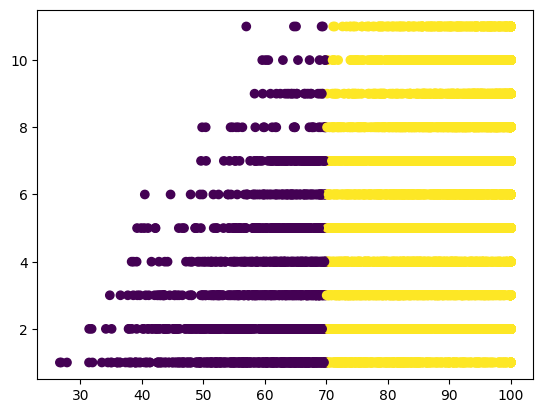

In [101]:
plt.scatter(df_new['exam_score'], df_new['study_hours'], c = df_new['placement_status'])

#using logistic regrassion

In [102]:
x= df_new.iloc[:,0:2]
y= df_new.iloc[:, -1]

In [103]:
x.shape

(10000, 2)

In [104]:
y.shape

(10000,)

In [111]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train ,y_test = train_test_split( x,y,test_size=0.1)

In [112]:
x_train

,study_hours,exam_score
2169,9,100.00
6976,10,100.00
7102,5,96.20
3878,8,85.61
5563,4,86.22
...,...,...
7506,8,100.00
8988,7,65.09
7688,5,88.37
2714,1,39.06


In [113]:
y_train

,placement_status
2169,1
6976,1
7102,1
3878,1
5563,1
...,...
7506,1
8988,0
7688,1
2714,0


In [114]:
x_test

,study_hours,exam_score
2779,10,59.58
176,8,100.00
2993,4,92.58
1700,2,87.79
6882,7,100.00
...,...,...
9181,5,100.00
2937,10,94.05
9438,4,81.86
6333,10,100.00


In [115]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.fit_transform(x_test)

In [116]:
x_train

array([[ 0.95496866,  0.88378993],
       [ 1.27121836,  0.88378993],
       [-0.31003012,  0.63146427],
       ...,
       [-0.31003012,  0.11154063],
       [-1.5750289 , -3.16271671],
       [-1.5750289 , -0.29218041]])

In [117]:
x_test

array([[ 1.23703166, -1.8122617 ],
       [ 0.60701808,  0.87585233],
       [-0.65300907,  0.38238854],
       ...,
       [-0.65300907, -0.33054026],
       [ 1.23703166,  0.87585233],
       [ 1.23703166,  0.87585233]])

In [118]:
#model ko train karna hai

In [119]:
from sklearn.linear_model import LogisticRegression

# After previous data processing, y_train should now contain both 0s and 1s without NaNs.
# Let's verify the class distribution in y_train before fitting.
print("Value counts of y_train before model fitting:")
print(y_train.value_counts())

model = LogisticRegression()
model.fit(x_train, y_train)

Value counts of y_train before model fitting:
placement_status
1    7520
0    1480
Name: count, dtype: int64


LogisticRegression()

In [120]:
#model evelutaion
model.fit(x_train , y_train)

LogisticRegression()

In [121]:
model.predict(x_test)


array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,

In [122]:
model.predict_proba(x_test)

array([[9.99892585e-01, 1.07415290e-04],
       [1.49213975e-12, 1.00000000e+00],
       [1.61453517e-09, 9.99999998e-01],
       ...,
       [2.59116123e-05, 9.99974088e-01],
       [1.29452005e-12, 1.00000000e+00],
       [1.29452005e-12, 1.00000000e+00]])

In [123]:
model.predict(x_train)

array([1, 1, 1, ..., 1, 0, 1])

In [127]:
y_pred = model.predict(x_test)

In [128]:
y_test

,placement_status
2779,0
176,1
2993,1
1700,1
6882,1
...,...
9181,1
2937,1
9438,1
6333,1


In [129]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test , y_pred)

0.997

we are importing library

In [130]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

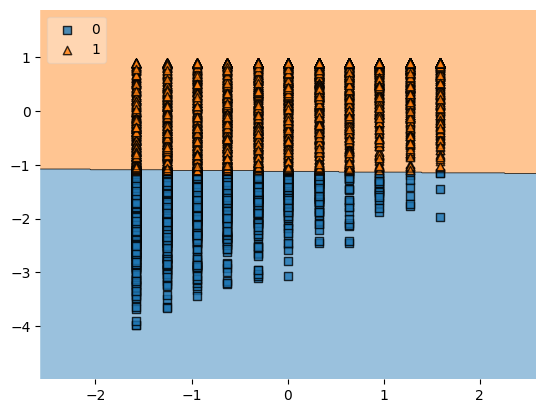

In [133]:
plot_decision_regions( x_train , y_train.values, clf=model, legend=2)

In [137]:
import pickle

In [136]:
pickle.dump(model,open('model.pkl', 'wb'))